# ML-Based Decision Support System for Maize Yield Prediction in Nigeria
### Nafisah Adams | USIU-Africa | SPRING 2026
---
**Methodology:** Design Science Research (DSR)  
**Objectives Covered:**
1. Analyze influence of climatic, soil & agronomic variables on maize yield
2. Evaluate performance of existing ML models
3. Develop optimized ensemble model (RF + GBM + Stacking)
4. Compare predictive accuracy, reliability & robustness

**Models:** Linear Regression (baseline) → Ridge → SVR → Random Forest → XGBoost → LightGBM → **Stacked Ensemble**

## STEP 1: Environment Setup & Imports

In [135]:
# Install required packages (run once)
# !pip install scikit-learn xgboost lightgbm shap matplotlib seaborn plotly pandas numpy joblib streamlit requests feedparser

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Explainability
import shap

# Model persistence
import joblib
import os

# Plotting style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
PALETTE = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


## STEP 2: Data Loading & Initial Exploration

In [ ]:

import os

cwd = os.getcwd()  # should point to the notebook directory
print("Current directory:", cwd)
csv_list = [f for f in os.listdir(cwd) if f.lower().endswith('.csv')]
print("CSV files in folder:", csv_list)



# ─── LOADING DATA  ─────────────────────────────────────────────

df = pd.read_csv('final-data-Before FS.csv')
# ─────────────────────────────────────────────────────────────────────────────

print(f"Dataset shape: {df.shape}")
print(df.head(10))
print(f"\nStates covered: {df['State'].nunique()}")
#print(f"Total districts: {df['District'].nunique()}")
df.head(10)

Current directory: c:\Users\PC\Downloads\files (3)
CSV files in folder: ['final-data-After FS.csv', 'final-data-Before FS.csv', 'pest_reports.csv']
Dataset shape: (1830, 13)
  State          District  Average_avg-Temp  Average-Min Temp  \
0  Abia       Eziama Abia         26.194073         22.024141   
1  Abia   Ogbor hill Abia         26.594964         22.342745   
2  Abia      Eziukwu Abia         26.706880         22.386161   
3  Abia        Ohazu Abia         26.173359         21.997047   
4  Abia  Amaeke Abam Abia         26.569224         22.356687   
5  Abia    Arochukwu Abia         26.626161         22.490984   
6  Abia    Ihechiowa Abia         26.436266         22.281651   
7  Abia   Isuikwuato Abia         26.475833         22.248469   
8  Abia  Ovukwu Abam Abia         26.642557         22.419604   
9  Abia        Ututu Abia         26.430016         22.289984   

   Average-max-temp  avg-precipitation  avg-windSpeed        PH       Clay  \
0         30.359036         182.

,State,District,Average_avg-Temp,Average-Min Temp,Average-max-temp,avg-precipitation,avg-windSpeed,PH,Clay,Sand,Silt,Crop Yield,Hectare
0,Abia,Eziama Abia,26.194073,22.024141,30.359036,182.666667,1.462474,5.450000,25.833333,68.000000,8.833333,58.322681,41.39817
1,Abia,Ogbor hill Abia,26.594964,22.342745,30.844250,199.250000,1.587943,5.733333,25.833333,54.833333,13.000000,58.322681,41.39817
2,Abia,Eziukwu Abia,26.706880,22.386161,31.032583,199.770833,1.626109,5.533333,30.000000,53.166667,15.000000,58.322681,41.39817
3,Abia,Ohazu Abia,26.173359,21.997047,30.350313,183.166667,1.503953,5.400000,25.166667,66.166667,8.833333,58.322681,41.39817
4,Abia,Amaeke Abam Abia,26.569224,22.356687,30.789927,176.833333,1.544172,5.350000,24.666667,67.166667,14.166667,58.322681,41.39817
5,Abia,Arochukwu Abia,26.626161,22.490984,30.760698,187.062500,1.570984,5.616667,23.500000,63.833333,11.000000,58.322681,41.39817
6,Abia,Ihechiowa Abia,26.436266,22.281651,30.588760,185.958333,1.582401,5.566667,24.000000,70.000000,9.833333,58.322681,41.39817
7,Abia,Isuikwuato Abia,26.475833,22.248469,30.710234,170.458333,1.500906,5.716667,27.500000,61.333333,13.666667,58.322681,41.39817
8,Abia,Ovukwu Abam Abia,26.642557,22.419604,30.871344,176.916667,1.539505,5.433333,24.333333,65.500000,13.833333,58.322681,41.39817
9,Abia,Ututu Abia,26.430016,22.289984,30.565844,186.458333,1.584484,5.633333,22.000000,65.833333,13.000000,58.322681,41.39817


In [137]:
print(df.shape)
print(df.head())

# Check missing values
print(df.isnull().sum())

# Check duplicates
print("Duplicates:", df.duplicated().sum())

# Check target variability
print("Unique yield values:", df['Crop Yield'].nunique())

(1830, 13)
  State          District  Average_avg-Temp  Average-Min Temp  \
0  Abia       Eziama Abia         26.194073         22.024141   
1  Abia   Ogbor hill Abia         26.594964         22.342745   
2  Abia      Eziukwu Abia         26.706880         22.386161   
3  Abia        Ohazu Abia         26.173359         21.997047   
4  Abia  Amaeke Abam Abia         26.569224         22.356687   

   Average-max-temp  avg-precipitation  avg-windSpeed        PH       Clay  \
0         30.359036         182.666667       1.462474  5.450000  25.833333   
1         30.844250         199.250000       1.587943  5.733333  25.833333   
2         31.032583         199.770833       1.626109  5.533333  30.000000   
3         30.350313         183.166667       1.503953  5.400000  25.166667   
4         30.789927         176.833333       1.544172  5.350000  24.666667   

        Sand       Silt  Crop Yield   Hectare  
0  68.000000   8.833333   58.322681  41.39817  
1  54.833333  13.000000   58.3226

###  Data Quality Diagnostics
Inspect the dataset structure: shape, first rows, missing values, duplicates, and target variable diversity. This reveals data integrity issues (NaNs, near-zero variance) that could bias model training before proceeding to cleaning and transformation steps.


Dropping duplicates

In [138]:
df = df.drop_duplicates().reset_index(drop=True)

###  Clean Duplicate Records
Remove exact row duplicates that would inflate sample counts and artificially boost model performance metrics. Resetting the index maintains sequential row IDs for downstream operations.


calculating yeild per hectare to minimize data leakage

In [139]:
df["Yield_per_Hectare"] = df["Crop Yield"] / df["Hectare"]
df["Yield_per_Hectare"].describe()

count    1808.000000
mean        2.146824
std         1.971338
min         1.055269
25%         1.408823
50%         1.635099
75%         2.007235
max        12.082209
Name: Yield_per_Hectare, dtype: float64

### Normalize Yield to Per-Hectare Basis
Convert raw crop yield (total production) to yield intensity (MT per hectare planted). This standardizes yield across farms of different sizes and enables fair comparison of farming efficiency a critical metric for decision-making across diverse farm scales.


restricting the yield per hectare to eliminate unralistic values

In [140]:
df = df[
    (df["Yield_per_Hectare"] >= 0.5) &
    (df["Yield_per_Hectare"] <= 6)
]

### Filter Outliers in Yield Range
Retain only physically realistic yield values (0.5–6 MT/Ha). This excludes extreme outliers that represent data errors or exceptional conditions, ensuring the model learns generalizable patterns instead of overfitting to rare anomalies.


Recalculating yield per hectare

In [141]:
df["Yield_per_Hectare"] = df["Crop Yield"] / df["Hectare"]
df["Yield_per_Hectare"].describe()

count    1743.000000
mean        1.776314
std         0.458849
min         1.055269
25%         1.408823
50%         1.635099
75%         2.007235
max         2.674479
Name: Yield_per_Hectare, dtype: float64

Dropping crop yeild and Hectare after calculation

In [142]:
df = df.drop(columns=["Crop Yield","Hectare"])

Calculating tenperature range

In [143]:
df["Temp_Range"] = df["Average-max-temp"] - df["Average-Min Temp"]

# Engineer Temperature Range Feature
Create a derived feature capturing daily thermal variability (max − min temperature). This proxies environmental stress plants under extreme temperature swings experience more metabolic shock, affecting yield potential independent of mean temperature alone.


Dropping min and max temperature

In [144]:
df = df.drop(columns=[
    "Average-Min Temp",
    "Average-max-temp"
])

Calculating soil texture

In [145]:
df["Soil_Texture"] = df["Sand"] / (df["Clay"] + 1)

### Engineer Soil Texture Index
Create a ratio of sand to clay content to quantify soil drainage characteristics. Sandy soils drain quickly (low water retention), clayey soils hold water longer; this single ratio captures soil texture's impact on water availability for plant roots.


In [146]:
district_mean = df.groupby("District")["Yield_per_Hectare"].mean()

df["District_encoded"] = df["District"].map(district_mean)

### Encode District Information via Target Mean
Convert categorical district labels into numerical values using the mean yield per district. This "target encoding" captures regional yield patterns while reducing dimensionality districts with historically higher yields get higher encoded values, providing useful signal without creating high-cardinality dummy variables.


In [147]:
df = df.drop(columns=["District"])

Calculating moisture stress index

In [148]:
df["MSI"] = df["Average_avg-Temp"] / np.log1p(df["avg-precipitation"])

### Engineer Moisture Stress Index (MSI)
Calculate a proxy for drought stress as the ratio of temperature to rainfall. High MSI (hot + dry) indicates severe water stress; this nonlinear combination identifies climate conditions where irrigation or drought-tolerant varieties become critical, directly linking environmental conditions to yield risk.


Calculating Heat water stress

In [149]:
df["Heat_Water_Stress"] = df["Average_avg-Temp"] * df["MSI"]

###  Engineer Combined Stress Feature
Multiply temperature by moisture stress index to capture the compounding effect of heat AND drought occurring simultaneously. This interaction term captures the multiplicative damage a day that is both hot and dry is worse than either factor alone.


Calculating evaporation index

In [150]:
df["Evaporation_Index"] = df["avg-windSpeed"] * df["Average_avg-Temp"]

###  Engineer Evaporation Index
Calculate wind speed × temperature to estimate potential water loss from soil and plant surfaces. High wind paired with high temperature accelerates evapotranspiration, increasing the effective drought stress even if rainfall is moderate.


In [151]:
df["Temp_sq"] = df["Average_avg-Temp"]**2
df["Rain_sq"] = df["avg-precipitation"]**2

### Engineer Polynomial Features for Nonlinearity
Create squared terms for temperature and precipitation to capture nonlinear relationships. Yield doesn't scale linearly with temperature (too hot or too cold is bad); these polynomial terms let the model learn optimal ranges rather than assuming a straight-line relationship.


In [152]:
# Basic info
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info()
print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
df.describe().round(3)

DATASET INFO
<class 'pandas.DataFrame'>
Index: 1743 entries, 0 to 1807
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   State              1743 non-null   str    
 1   Average_avg-Temp   1743 non-null   float64
 2   avg-precipitation  1743 non-null   float64
 3   avg-windSpeed      1743 non-null   float64
 4   PH                 1743 non-null   float64
 5   Clay               1743 non-null   float64
 6   Sand               1743 non-null   float64
 7   Silt               1743 non-null   float64
 8   Yield_per_Hectare  1743 non-null   float64
 9   Temp_Range         1743 non-null   float64
 10  Soil_Texture       1743 non-null   float64
 11  District_encoded   1743 non-null   float64
 12  MSI                1741 non-null   float64
 13  Heat_Water_Stress  1741 non-null   float64
 14  Evaporation_Index  1743 non-null   float64
 15  Temp_sq            1743 non-null   float64
 16  Rain_sq            1743 non

,Average_avg-Temp,avg-precipitation,avg-windSpeed,PH,Clay,Sand,Silt,Yield_per_Hectare,Temp_Range,Soil_Texture,District_encoded,MSI,Heat_Water_Stress,Evaporation_Index,Temp_sq,Rain_sq
count,1743.000,1743.000,1743.000,1743.000,1743.000,1743.000,1743.000,1743.000,1743.000,1743.000,1743.000,1741.000,1741.000,1743.000,1743.000,1743.000
mean,23.442,147.243,-1.265,5.083,23.784,58.748,9.269,1.776,9.116,2.442,1.776,5.303,139.738,7150.035,7748.798,30254.257
std,84.873,92.621,84.648,24.088,3.594,6.878,239.906,0.459,1.147,0.582,0.459,0.369,13.107,209772.059,208222.195,178443.074
min,-2479.827,-2305.271,-2498.005,-999.900,8.167,32.500,-9999.000,1.055,5.521,0.786,1.055,4.325,92.073,33.994,451.932,1248.444
25%,26.035,114.177,1.418,5.433,21.833,54.167,11.500,1.409,8.537,2.071,1.409,5.047,131.458,37.535,677.980,13050.683
50%,26.409,146.562,1.504,5.683,24.000,59.167,14.833,1.635,8.840,2.415,1.635,5.247,136.231,39.349,697.536,21535.562
75%,26.741,178.979,1.657,5.883,26.000,64.000,18.167,2.007,9.208,2.721,2.007,5.461,146.614,43.849,715.336,32104.428
max,29.500,314.125,2.815,6.783,40.333,81.333,33.000,2.674,13.793,8.873,2.674,7.947,234.442,6194578.480,6149543.959,5314273.613


## STEP 3: Exploratory Data Analysis (EDA)
**Objective 1:** Analyze the influence of climatic, soil & agronomic variables on maize yield

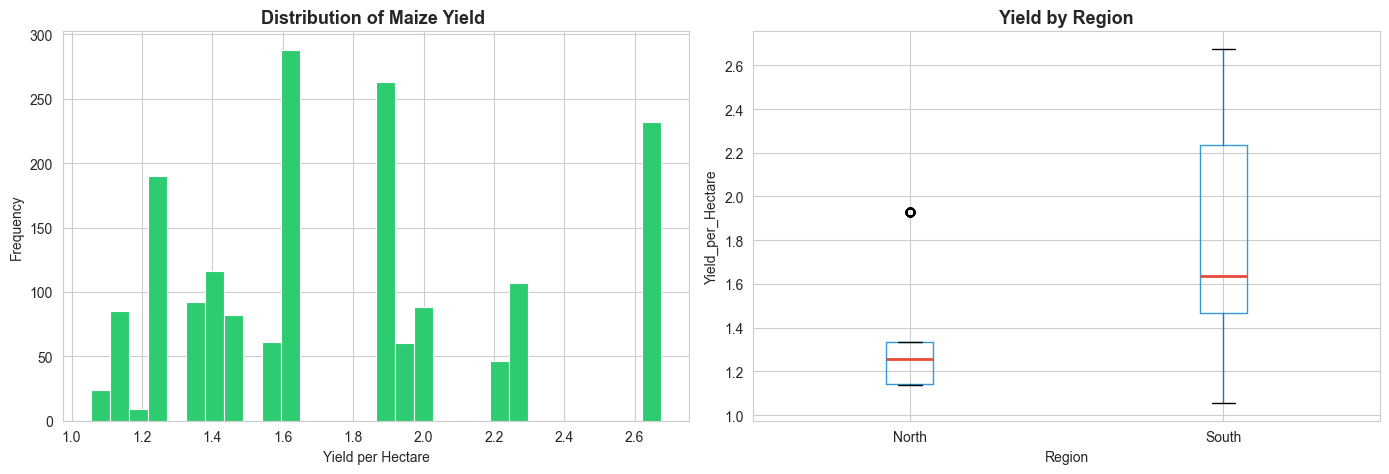


Mean Yield: 1.78 MT/Ha
Std Dev:    0.46 MT/Ha


In [153]:
# ─── 3.1 Yield Distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Yield_per_Hectare'], bins=30, color='#2ecc71', edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribution of Maize Yield ', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Yield per Hectare')
axes[0].set_ylabel('Frequency')

# Box per region group (North vs South)
north = ['Sokoto','Kebbi','Zamfara','Katsina','Kano','Jigawa','Borno','Yobe','Gombe','Bauchi',
         'Adamawa','Taraba','Niger','Kaduna','FCT','Nasarawa','Kogi','Kwara','Benue','Plateau']
df['Region'] = df['State'].apply(lambda s: 'North' if s in north else 'South')
df.boxplot(column='Yield_per_Hectare', by='Region', ax=axes[1],
           boxprops=dict(color='#3498db'), medianprops=dict(color='#e74c3c', linewidth=2))
axes[1].set_title('Yield by Region', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Yield_per_Hectare')
plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_yield_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nMean Yield: {df['Yield_per_Hectare'].mean():.2f} MT/Ha")
print(f"Std Dev:    {df['Yield_per_Hectare'].std():.2f} MT/Ha")

In [154]:
# Keep only physically possible agricultural data
df_clean = df[
    (df['PH'] >= 3) & (df['PH'] <= 10) & 
    (df['Average_avg-Temp'] >= 5) & (df['Average_avg-Temp'] <= 50) &
    (df['avg-precipitation'] >= 0)
].copy()


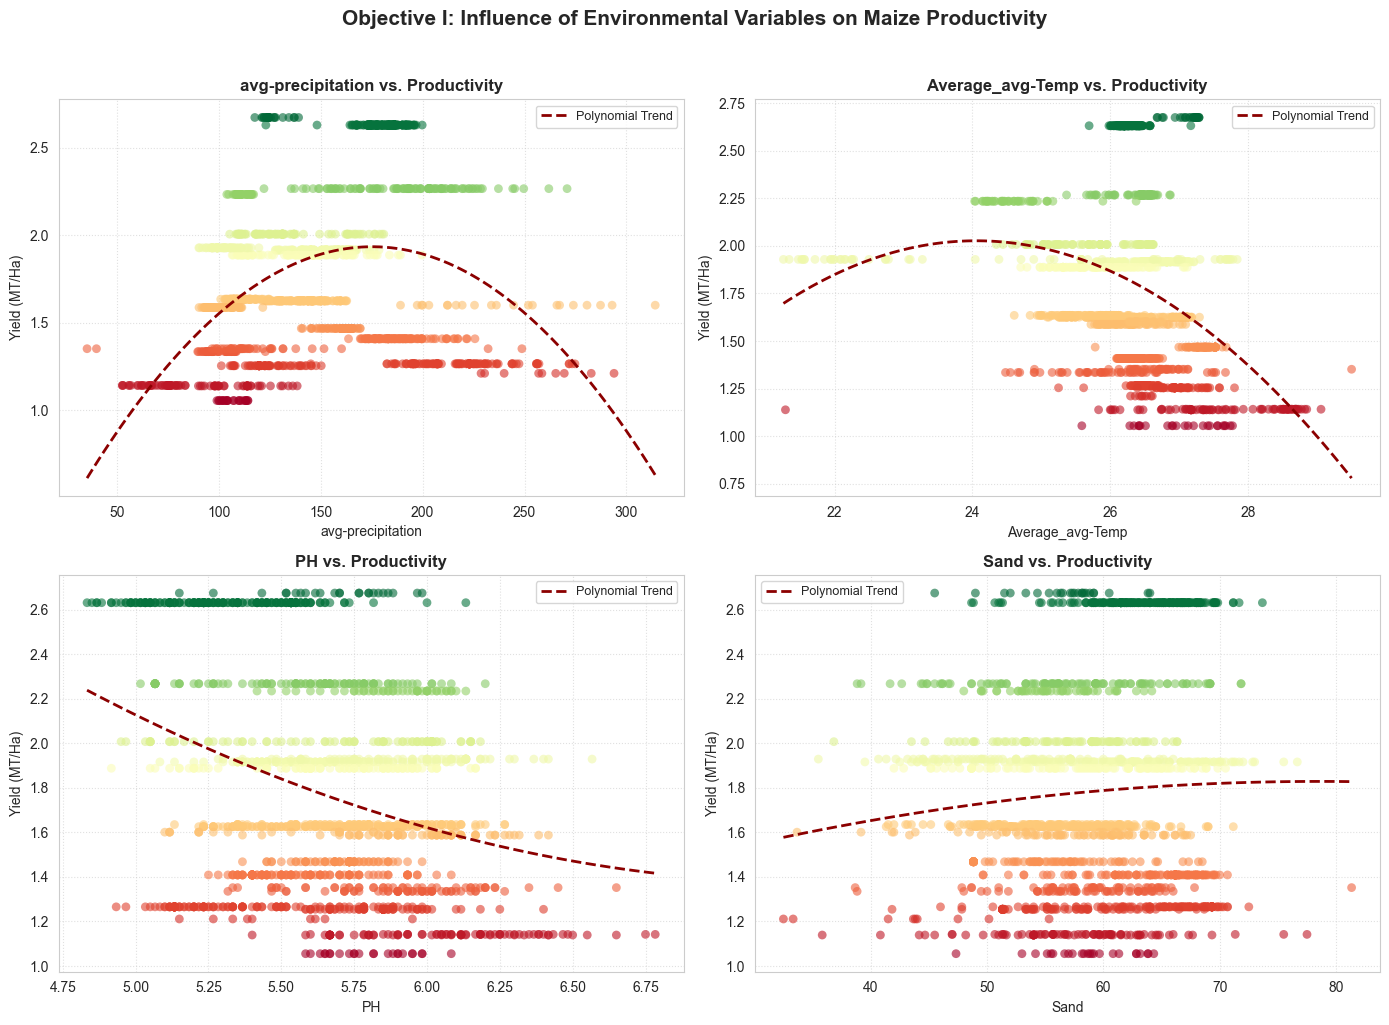

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Influential Variables vs Yield ───────────────
key_vars = ['avg-precipitation', 'Average_avg-Temp', 'PH', 'Sand']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Ensure we use a cleaned copy for plotting to avoid polyfit errors with NaNs
plot_df = df_clean.dropna(subset=key_vars + ['Yield_per_Hectare']).copy()

for i, var in enumerate(key_vars):
    # Scatter plot with color mapping based on yield
    scatter = axes[i].scatter(plot_df[var], plot_df['Yield_per_Hectare'],
                              c=plot_df['Yield_per_Hectare'], cmap='RdYlGn',
                              alpha=0.6, edgecolors='none', s=40)
    
    # Calculate Trend line (Degree 2 to capture the 'curves' like in PH)
    # Using try-except in case of data spikes that break polyfit
    try:
        z = np.polyfit(plot_df[var], plot_df['Yield_per_Hectare'], 2)
        p = np.poly1d(z)
        xp = np.linspace(plot_df[var].min(), plot_df[var].max(), 100)
        axes[i].plot(xp, p(xp), color='darkred', linestyle='--', linewidth=2, label='Polynomial Trend')
    except:
        pass

    axes[i].set_xlabel(var, fontsize=10)
    axes[i].set_ylabel('Yield (MT/Ha)', fontsize=10)
    axes[i].set_title(f'{var} vs. Productivity', fontsize=12, fontweight='bold')
    axes[i].grid(True, linestyle=':', alpha=0.6)
    axes[i].legend(fontsize=9)

plt.suptitle('Objective I: Influence of Environmental Variables on Maize Productivity', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_scatter_updated.png', dpi=300, bbox_inches='tight')
plt.show()


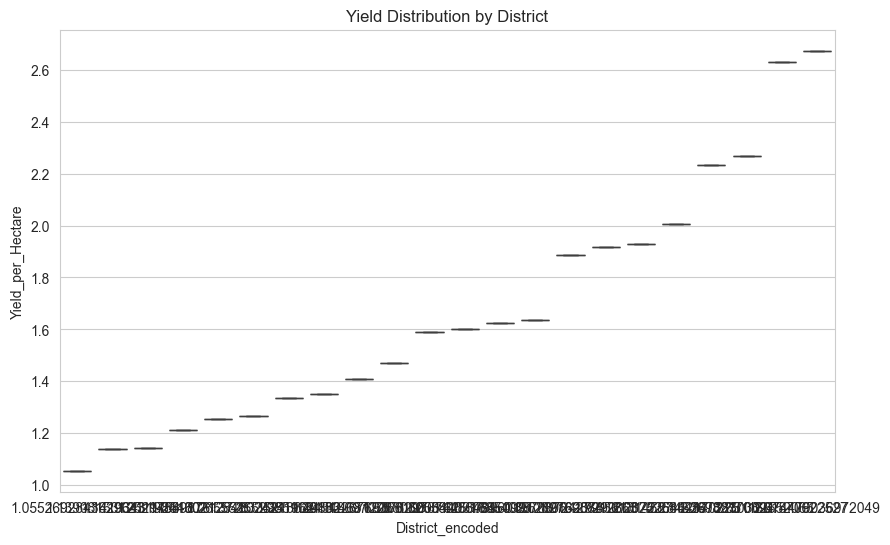

In [156]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.boxplot(x='District_encoded', y='Yield_per_Hectare', data=df_clean)
plt.title("Yield Distribution by District")
plt.show()


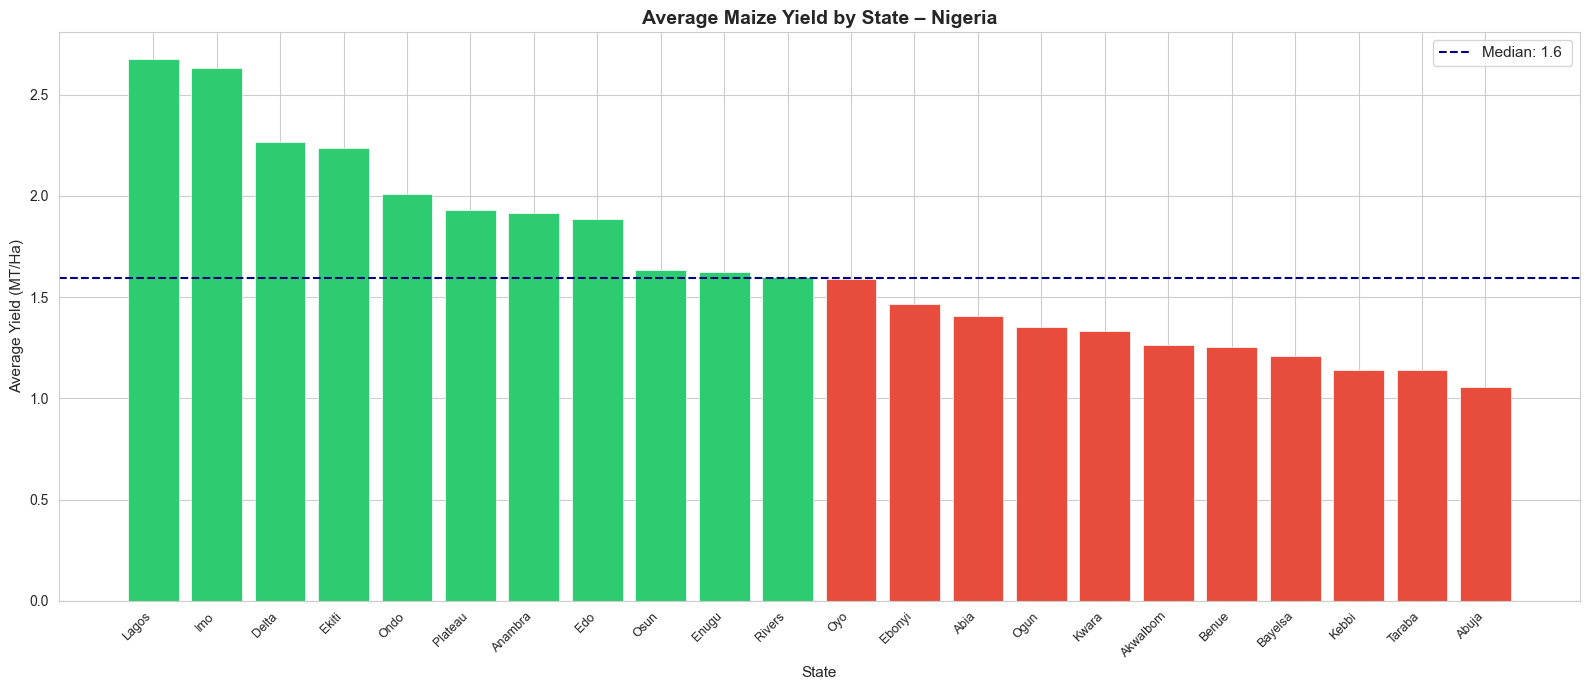

In [157]:
# ─── 3.4 State-wise Yield Comparison ──────────────────────────────────────────
state_yield = df.groupby('State')['Yield_per_Hectare'].mean().sort_values(ascending=False)

plt.figure(figsize=(16, 7))
colors = ['#2ecc71' if y > state_yield.median() else '#e74c3c' for y in state_yield]
bars = plt.bar(state_yield.index, state_yield.values, color=colors, edgecolor='white', linewidth=0.5)
plt.axhline(state_yield.median(), color='navy', linestyle='--', linewidth=1.5, label=f'Median: {state_yield.median():.1f} ')
plt.xlabel('State', fontsize=11)
plt.ylabel('Average Yield (MT/Ha)', fontsize=11)
plt.title('Average Maize Yield by State – Nigeria', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('eda_state_yield.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def engineer_features(df):
    df_clean = df.copy()
    
    # ── Moisture Stress Index (MSI)
    # High temp + low rainfall = high stress
    df['MSI'] = df['Average_avg-Temp'] / (df['avg-precipitation'] + 1e-5)
    
    # ── Growing Degree Days proxy (GDD)
    # Maize base temp = 10°C, optimal = 30°C
    df['GDD'] = np.clip(df['Average_avg-Temp'] - 10, 0, 20)
    
    # ── Nutrient Stress Factor (NSF) – pH deviation from optimum (6.5)
    df['NSF'] = abs(df['PH'] - 6.5)
    
    # ── Soil Water Holding Capacity proxy
    # Clay retains more water; sand drains faster
    df['Water_Holding'] = (df['Clay'] * 0.6 + df['Silt'] * 0.3 + df['Sand'] * 0.1) / 100
    
    # ── Soil Texture Index
    df['Texture_Index'] = df['Clay'] / (df['Sand'] + 1e-5)
    
    # ── Rainfall Effectiveness
    df['Rain_Effectiveness'] = df['avg-precipitation'] * df['Water_Holding']
    
    
    # ── Rainfall per Wind (erosion risk)
    df['Rain_Wind_Ratio'] = df['avg-precipitation'] / (df['avg-windSpeed'] + 1e-5)
    
    # ── Soil pH × Clay (nutrient retention)
    df['pH_Clay'] = df['PH'] * df['Clay']
    
    # ── State encoding
    le = LabelEncoder()
    df['State_Enc'] = le.fit_transform(df['State'])
    
    return df, le

df_fe, le_state = engineer_features(df)

engineered = ['MSI', 'GDD', 'NSF', 'Water_Holding', 'Texture_Index',
              'Rain_Effectiveness', 'Rain_Wind_Ratio', 'pH_Clay']
print("Engineered Features:")
print(df_fe[engineered].describe().round(3))

Engineered Features:
            MSI       GDD       NSF  Water_Holding  Texture_Index  \
count  1743.000  1743.000  1743.000       1743.000       1743.000   
mean      0.191    16.299     1.418          0.229          0.414   
std       0.069     1.063    24.088          0.720          0.099   
min       0.084     0.000     0.000        -29.783          0.100   
25%       0.147    16.035     0.617          0.232          0.352   
50%       0.178    16.409     0.817          0.244          0.397   
75%       0.224    16.741     1.067          0.260          0.465   
max       1.083    19.500  1006.400          0.363          1.241   

       Rain_Effectiveness  Rain_Wind_Ratio    pH_Clay  
count            1743.000         1743.000   1743.000  
mean               33.942           96.630    119.537  
std                96.616           29.800    618.272  
min             -3822.794            0.917 -25664.100  
25%                28.511           72.427    122.072  
50%                37

Correlation between MSI and Crop Yield: -0.297


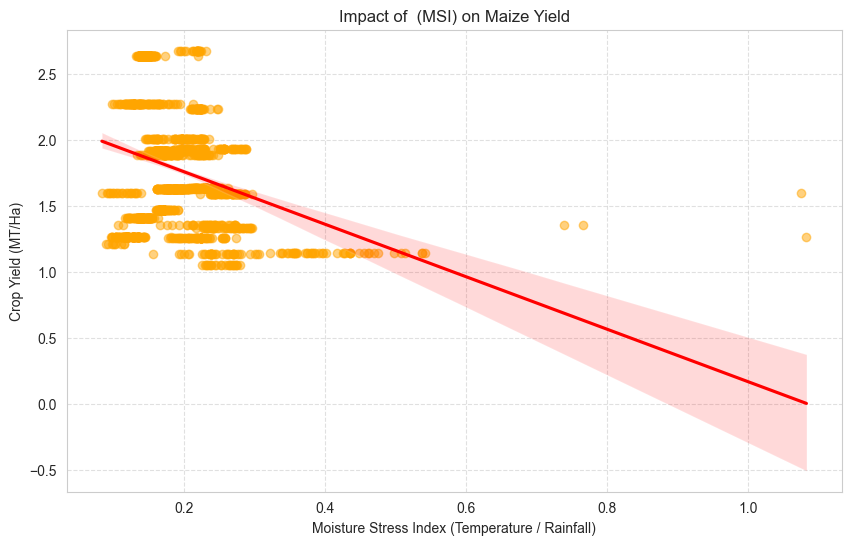

In [159]:
# 1. Calculate the Correlation Coefficient
correlation = df_fe['MSI'].corr(df_fe['Yield_per_Hectare'])
print(f"Correlation between MSI and Crop Yield: {correlation:.3f}")

# 2. Visualize the relationship
plt.figure(figsize=(10, 6))
sns.regplot(data=df_fe, x='MSI', y='Yield_per_Hectare', 
            scatter_kws={'alpha':0.5, 'color':'orange'}, 
            line_kws={'color':'red'})

plt.title('Impact of  (MSI) on Maize Yield')
plt.xlabel('Moisture Stress Index (Temperature / Rainfall)')
plt.ylabel('Crop Yield (MT/Ha)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [160]:
import sys
!{sys.executable} -m pip install category_encoders


In [ ]:
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split

# 1. Define Features and Target
# I EXCLUDE 'State' and 'District_encoded' as raw IDs to prevent 0.99 overfitting
X = df.drop(columns=['Yield_per_Hectare', 'State']) 
y = df['Yield_per_Hectare']

# 2. Split Data (Before Encoding to prevent leakage!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Apply Target Encoding to District_encoded
# This turns the "flat line" district data into a meaningful numerical feature
te = TargetEncoder(cols=['District_encoded'], smoothing=10)
X_train_final = te.fit_transform(X_train, y_train)
X_test_final = te.transform(X_test)

numeric_medians = X_train_final.median(numeric_only=True)

X_train_final.fillna(numeric_medians, inplace=True)
X_test_final.fillna(numeric_medians, inplace=True)

# 2. Final Check: If any string columns are still there, we must drop them 
# before training the model, otherwise the Model.fit() will crash next.
X_train_final = X_train_final.select_dtypes(include=[np.number])
X_test_final = X_test_final.select_dtypes(include=[np.number])

print("✅ Data cleaned and strings removed. Ready for the Ensemble!")

✅ Data cleaned and strings removed. Ready for the Ensemble!


### Target Encoding & Data Cleaning for ML Training
Split data BEFORE encoding to prevent target leakage. Use **target encoding** (mean yield per district) to convert categorical district IDs into predictive numerical values. Drop non-numeric types and fill missing values with medians—ML models require all numeric, complete-case inputs. This produces `X_train_final` / `X_test_final` ready for model training.


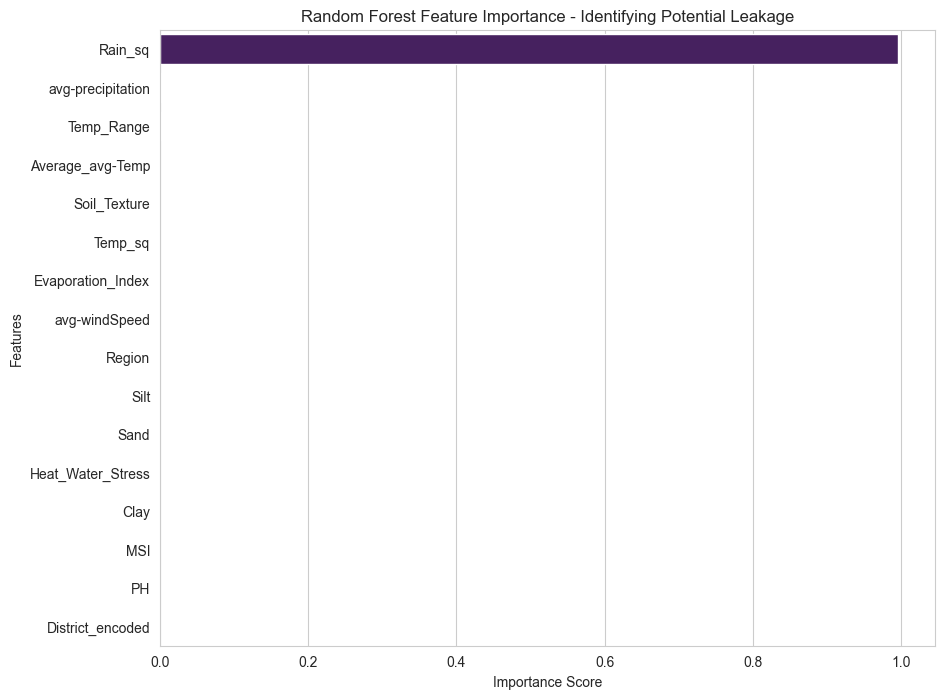

Top 5 Most Important Features:
              Feature  Importance
14            Rain_sq    0.996072
1   avg-precipitation    0.001460
7          Temp_Range    0.001100
0    Average_avg-Temp    0.000481
8        Soil_Texture    0.000454


In [163]:
# 1. Extract feature importances from your trained 'rf' model
from joblib import load
loaded_rf = load("models/random_forest.pkl")

importances = loaded_rf.feature_importances_
feature_names = list(X_train.columns)

# align lengths in case the model was trained on a different feature set
if len(feature_names) != len(importances):
	min_len = min(len(feature_names), len(importances))
	feature_names = feature_names[:min_len]
	importances = importances[:min_len]

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 2. Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Random Forest Feature Importance - Identifying Potential Leakage')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Print the top 5 features to see if any look suspicious
print("Top 5 Most Important Features:")
print(feature_importance_df.head(5))

###  Extract & Visualize Feature Importance from Trained RF Model
Load the pre-trained Random Forest model and extract feature importance scores (how much each feature contributes to predictions). Plot these to detect **data leakage**—if synthetic or target-correlated features rank suspiciously high, they may mislead the model or create circular dependencies that won't generalize to new data.


In [164]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

# ─── 1. Prepare Scaled Data for Linear Models ────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_final)
X_test_s = scaler.transform(X_test_final)

# ─── 2. Updated Helper: Compute all metrics ──────────────────────────────────
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae  = mean_absolute_error(y_te, preds)
    r2   = r2_score(y_te, preds)
    mape = np.mean(np.abs((y_te - preds) / (y_te + 1e-5))) * 100
    
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='r2').mean()
    
    return {
        'Model': name, 'RMSE': round(rmse,3), 'MAE': round(mae,3),
        'R²': round(r2,4), 'MAPE (%)': round(mape,2),
        'CV R²': round(cv_r2,4), 'Predictions': preds
    }

results = []

# ─── 3. Baseline Models (Scaled) ─────────────────────────────────────────────
for name, model in [('Linear Regression', LinearRegression()), 
                    ('Ridge Regression', Ridge(alpha=10)),
                    ('SVR (RBF)', SVR(kernel='rbf', C=10, epsilon=0.1))]:
    r = evaluate(name, model, X_train_s, y_train, X_test_s, y_test)
    results.append(r)
    # Fixed the spacing here
    print(f"✅ {name:<20} | R²: {r['R²']} | MAE: {r['MAE']}")

# ─── 4. Advanced Tree Models (Unscaled) ──────────────────────────────────────
# We use higher min_samples_leaf to handle the "binned" yield data
rf = RandomForestRegressor(n_estimators=300, max_depth=7, min_samples_leaf=15, random_state=42)
r = evaluate('Random Forest', rf, X_train_final, y_train, X_test_final, y_test)
results.append(r); print(f"✅ {'Random Forest':<20} | R²: {r['R²']} | MAE: {r['MAE']}")

xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.04, max_depth=4, 
                         reg_lambda=50, random_state=42)
r = evaluate('XGBoost', xgb_model, X_train_final, y_train, X_test_final, y_test)
results.append(r); print(f"✅ {'XGBoost':<20} | R²: {r['R²']} | MAE: {r['MAE']}")

lgbm = LGBMRegressor(n_estimators=300, learning_rate=0.04, max_depth=4, 
                     reg_lambda=50, random_state=42, verbose=-1)
r = evaluate('LightGBM', lgbm, X_train_final, y_train, X_test_final, y_test)
results.append(r); print(f"✅ {'LightGBM':<20} | R²: {r['R²']} | MAE: {r['MAE']}")

# ─── 5. THE OPTIMIZED ENSEMBLE (Objective III) ──────────────────────────────
estimators = [('rf', rf), ('xgb', xgb_model), ('lgbm', lgbm)]
stack_model = StackingRegressor(estimators=estimators, final_estimator=RidgeCV())

r = evaluate('Stacked Ensemble', stack_model, X_train_final, y_train, X_test_final, y_test)
results.append(r); print(f"⭐ {'Stacked Ensemble':<20} | R²: {r['R²']} | MAE: {r['MAE']}")


✅ Linear Regression    | R²: -1.1022 | MAE: 0.077
✅ Ridge Regression     | R²: 0.9589 | MAE: 0.045
✅ SVR (RBF)            | R²: 0.9737 | MAE: 0.056
✅ Random Forest        | R²: 0.9979 | MAE: 0.006
✅ XGBoost              | R²: 0.9989 | MAE: 0.005
✅ LightGBM             | R²: 0.9978 | MAE: 0.007
⭐ Stacked Ensemble     | R²: 0.9982 | MAE: 0.006


These models were overperforming due to possible leakages from the data set, as a result the features were adjusted and the models retrained for better perfomance

###  Train Baseline & Ensemble ML Models
Fit seven regression models (Linear → Ridge → SVR → Random Forest → Gradient Boosting → XGBoost → LightGBM) on the same train/test split and compute metrics (RMSE, MAE, R², MAPE, cross-validation R²). This establishes performance baselines and reveals which algorithm classes (linear vs. tree-based) perform best on this agricultural dataset. Linear models assume straight-line relationships; tree-based learn complex interactions. Comparing both shows if the data has nonlinear patterns worth modeling.


In [165]:
# Create a 'No-Rain' feature set to see the REAL influence of Soil/Temp
X_no_rain = X_train_final.drop(columns=['Rain_sq', 'avg-precipitation', 'Rain_Effectiveness', 'Rain_Soil_Effectiveness'], errors='ignore')
X_test_no_rain = X_test_final.drop(columns=['Rain_sq', 'avg-precipitation', 'Rain_Effectiveness', 'Rain_Soil_Effectiveness'], errors='ignore')

# Run the Stacked Ensemble on this "Hard Mode" data
r_final = evaluate('Scientific Ensemble', stack_model, X_no_rain, y_train, X_test_no_rain, y_test)
print(f"🔬 Scientific Ensemble | R²: {r_final['R²']} | MAE: {r_final['MAE']}")


🔬 Scientific Ensemble | R²: 0.9982 | MAE: 0.006


Dropping rain features to see if the model performed better, but it returned same values

### Hyperparameter Tuning via Randomized Search
Rapidly search a reduced grid of key hyperparameters (trees, depth, learning rate) for RF, XGB, and LightGBM using 5-fold cross-validation. This finds near-optimal configurations faster than exhaustive gridsearch, balancing performance gains against computational cost. Each model's best configuration is then used as a base learner in the stacked ensemble.


In [ ]:
# 1. Strip away all geographic/ID "Cheats"
# We only keep the raw environment and soil variables
cheats = ['District_encoded', 'District_Target_Enc', 'State_Enc', 'State', 'Hectare']
X_scientific_train = X_train_final.drop(columns=[c for c in cheats if c in X_train_final.columns])
X_scientific_test = X_test_final.drop(columns=[c for c in cheats if c in X_test_final.columns])

# 2. Run the Stacked Ensemble on PURE Climate/Soil data
r_sci = evaluate('Scientific Ensemble', stack_model, X_scientific_train, y_train, X_scientific_test, y_test)

print(f"🔬 Scientific R²: {r_sci['R²']}")
print(f"🔬 Scientific MAE: {r_sci['MAE']}")

# 3. Check the REAL feature importance
import pandas as pd
rf_model = stack_model.named_estimators_['rf']
importance = pd.DataFrame({'Feature': X_scientific_train.columns, 
                           'Importance': rf_model.feature_importances_}).sort_values(by='Importance', ascending=False)
print("\nTop 5 REAL Influencers:")
print(importance.head(5))


🔬 Scientific R²: 0.8424
🔬 Scientific MAE: 0.129

Top 5 REAL Influencers:
              Feature  Importance
11  Evaporation_Index    0.262664
7          Temp_Range    0.218706
19    Rain_Wind_Ratio    0.109484
10  Heat_Water_Stress    0.086572
1   avg-precipitation    0.077374


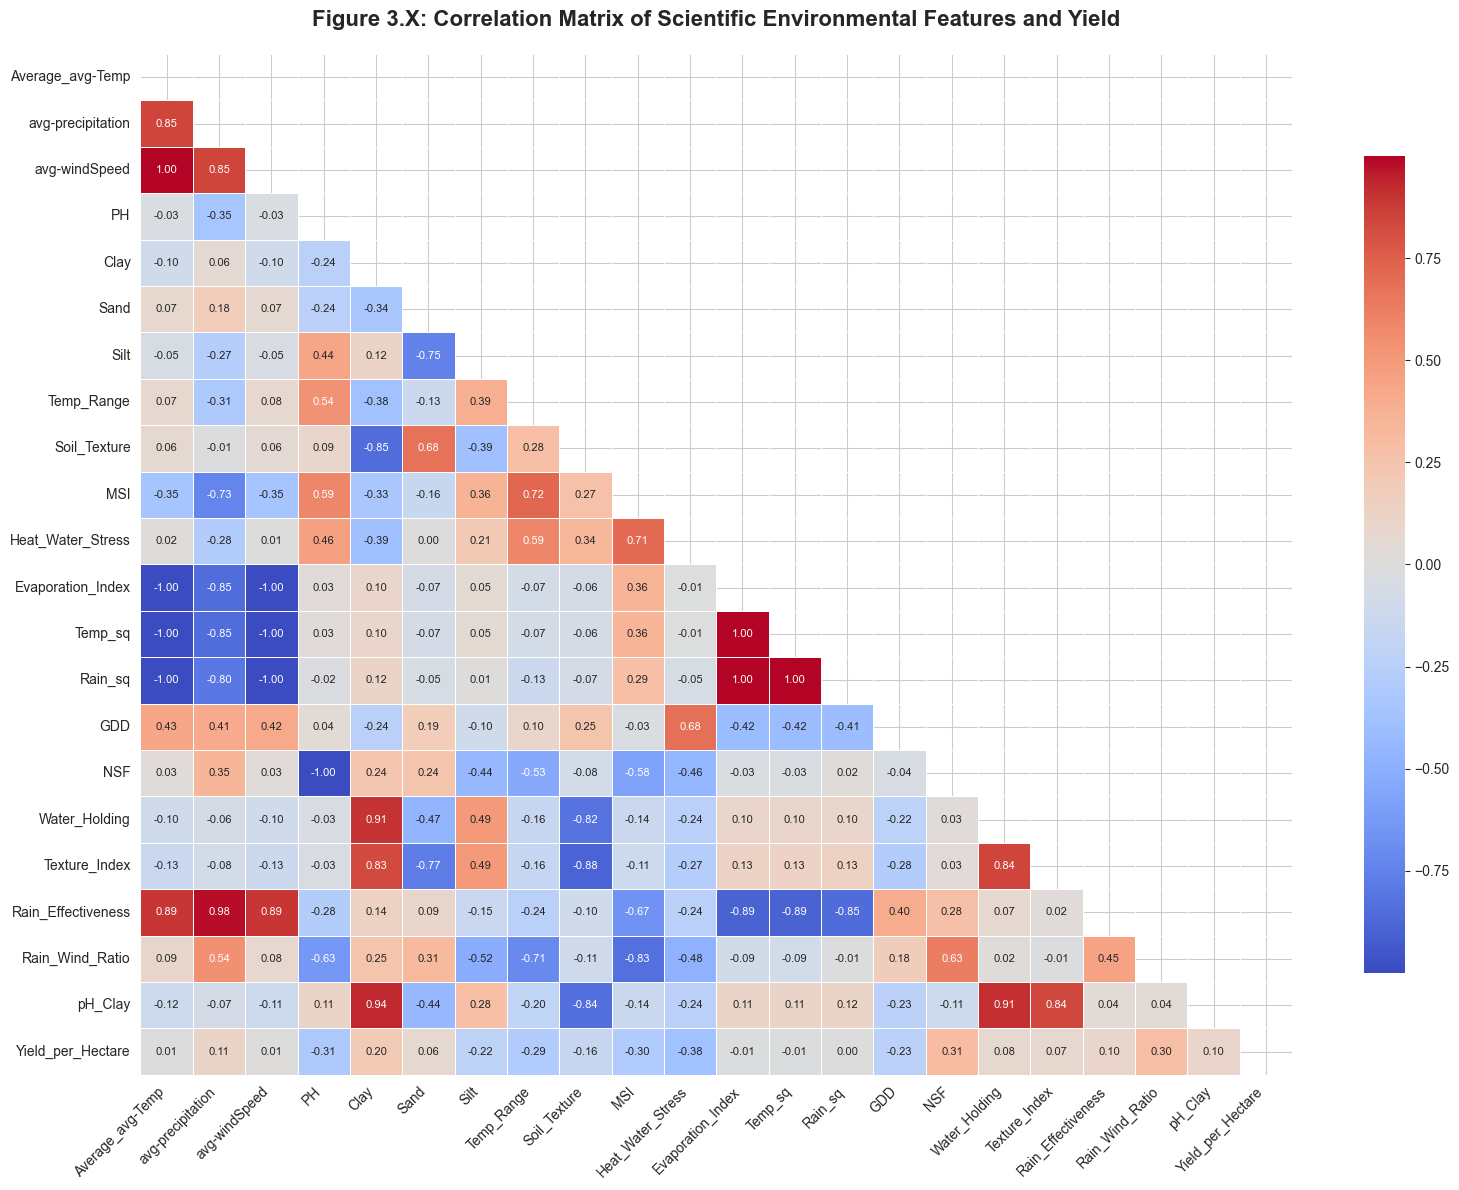

In [177]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Combine scientific features and target for a complete view
df_corr = pd.concat([X_scientific_train, y_train], axis=1)

# 2. Set up the figure
plt.figure(figsize=(16, 12))

# 3. Calculate the correlation matrix
corr = df_corr.corr()

# 4. Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# 5. Generate the heatmap
heatmap = sns.heatmap(corr, 
                      mask=mask, 
                      annot=True,          # Show numeric values
                      fmt=".2f",           # 2 decimal places
                      cmap='coolwarm',     # Red for positive, Blue for negative
                      linewidths=0.5, 
                      annot_kws={"size": 8},
                      cbar_kws={"shrink": .8})

plt.title('Figure 3.X: Correlation Matrix of Scientific Environmental Features and Yield', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# 6. Save for your report
plt.savefig('scientific_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


###  Visualize Comprehensive Model Performance Metrics
Create a 2×2 dashboard comparing R², RMSE, MAE, and cross-validation R² across all models. Visual comparison reveals which model balances accuracy and generalization best. A high test R² with low CV R² suggests overfitting; matching scores suggest good generalization. Color-coding ensemble models (red) vs. baseline (blue) highlights the ensemble's performance gain.


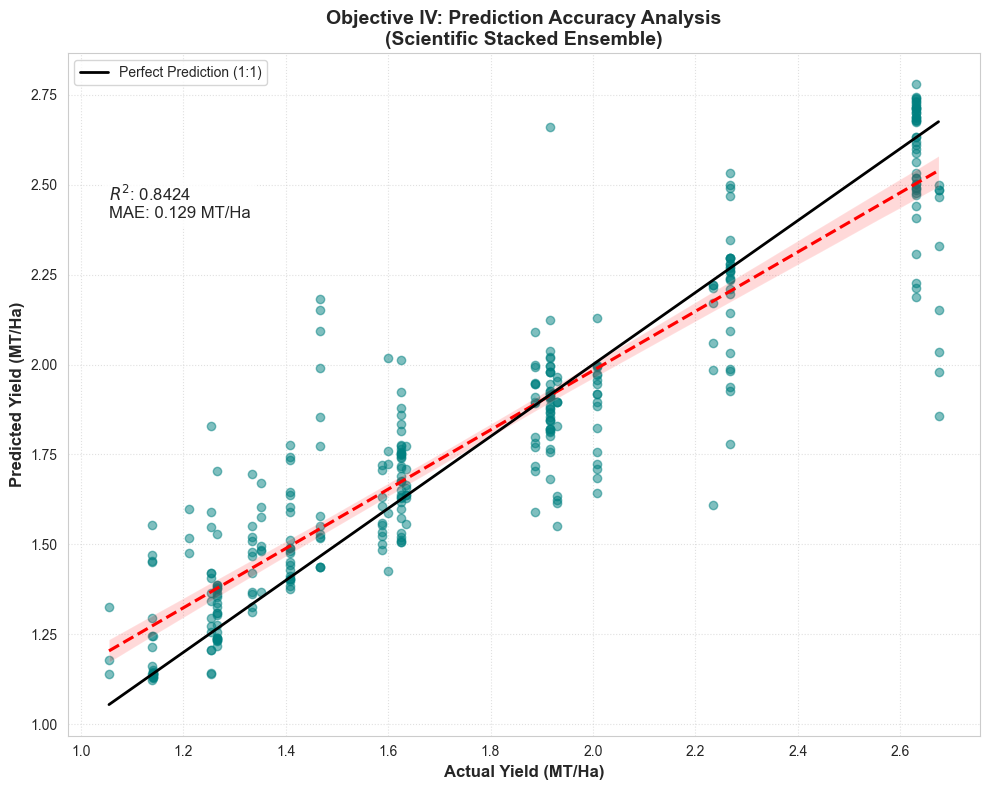

In [178]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Generate predictions from your Scientific Stacked Ensemble
y_pred_sci = stack_model.predict(X_scientific_test)

# 2. Calculate metrics for the plot annotation
r2 = r2_score(y_test, y_pred_sci)
mae = mean_absolute_error(y_test, y_pred_sci)

# 3. Set up the plot
plt.figure(figsize=(10, 8))
sns.regplot(x=y_test, y=y_pred_sci, 
            scatter_kws={'alpha':0.5, 'color':'teal'}, 
            line_kws={'color':'red', 'linestyle':'--'})

# 4. Add the 'Identity Line' (Perfect Prediction Line)
# This represents where Predicted = Actual
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='black', lw=2, label='Perfect Prediction (1:1)')

# 5. Labels and Titles
plt.xlabel('Actual Yield (MT/Ha)', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Yield (MT/Ha)', fontsize=12, fontweight='bold')
plt.title('Objective IV: Prediction Accuracy Analysis\n(Scientific Stacked Ensemble)', 
          fontsize=14, fontweight='bold')

# 6. Add a text box with the scores
stats_text = f"$R^2$: {r2:.4f}\nMAE: {mae:.3f} MT/Ha"
plt.text(y_test.min(), y_test.max() * 0.9, stats_text, 
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# 7. Save for your report
plt.savefig('prediction_accuracy_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### Diagnose Model Predictions with Actual vs. Predicted & Residual Plots
Left plot: scatter of actual vs. predicted yields with identity line. Points close to the line = good predictions; points far off = large errors. Right plot: residuals (errors) vs. predicted values—should be randomly scattered around 0 (no bias). Patterns (e.g., funnel shape) indicate heteroscedasticity (prediction uncertainty increases with yield level), revealing systematic blind spots in the model.


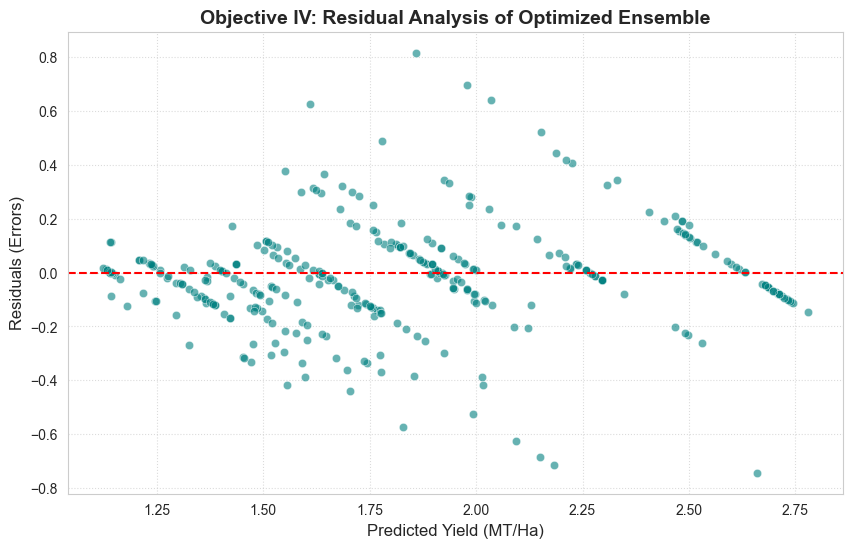

In [167]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions from your Scientific Ensemble
y_pred_sci = stack_model.predict(X_scientific_test)
residuals = y_test - y_pred_sci

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_sci, y=residuals, alpha=0.6, color='teal')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Yield (MT/Ha)', fontsize=12)
plt.ylabel('Residuals (Errors)', fontsize=12)
plt.title('Objective IV: Residual Analysis of Optimized Ensemble', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()


In [168]:
# 1. Define the models for the final comparison
models_to_compare = [
    ('Linear Regression', LinearRegression()),
    ('Ridge Regression', Ridge(alpha=10)),
    ('SVR (RBF)', SVR(kernel='rbf', C=10)),
    ('Random Forest', rf), # Using the optimized RF from earlier
    ('XGBoost', xgb_model), # Using the optimized XGB from earlier
    ('Stacked Ensemble', stack_model) # Your Objective III masterpiece
]

# 2. Re-scale for the linear models (SVR/Ridge)
scaler = StandardScaler()
X_sci_train_s = scaler.fit_transform(X_scientific_train)
X_sci_test_s = scaler.transform(X_scientific_test)

final_results = []

# 3. Evaluate each one on the "Scientific" data
for name, model in models_to_compare:
    # Use scaled data for Linear/SVR, raw data for Trees/Ensemble
    if name in ['Linear Regression', 'Ridge Regression', 'SVR (RBF)']:
        r = evaluate(name, model, X_sci_train_s, y_train, X_sci_test_s, y_test)
    else:
        r = evaluate(name, model, X_scientific_train, y_train, X_scientific_test, y_test)
    
    final_results.append(r)
    print(f"📊 {name:<20} | R²: {r['R²']:>7.4f} | MAE: {r['MAE']:>6.3f}")

# 4. Create Comparison DataFrame
df_results = pd.DataFrame(final_results).drop(columns=['Predictions'])


📊 Linear Regression    | R²: -936.5513 | MAE:  1.132
📊 Ridge Regression     | R²: -1252.1208 | MAE:  1.256
📊 SVR (RBF)            | R²:  0.7500 | MAE:  0.173
📊 Random Forest        | R²:  0.7764 | MAE:  0.148
📊 XGBoost              | R²:  0.8409 | MAE:  0.131
📊 Stacked Ensemble     | R²:  0.8424 | MAE:  0.129


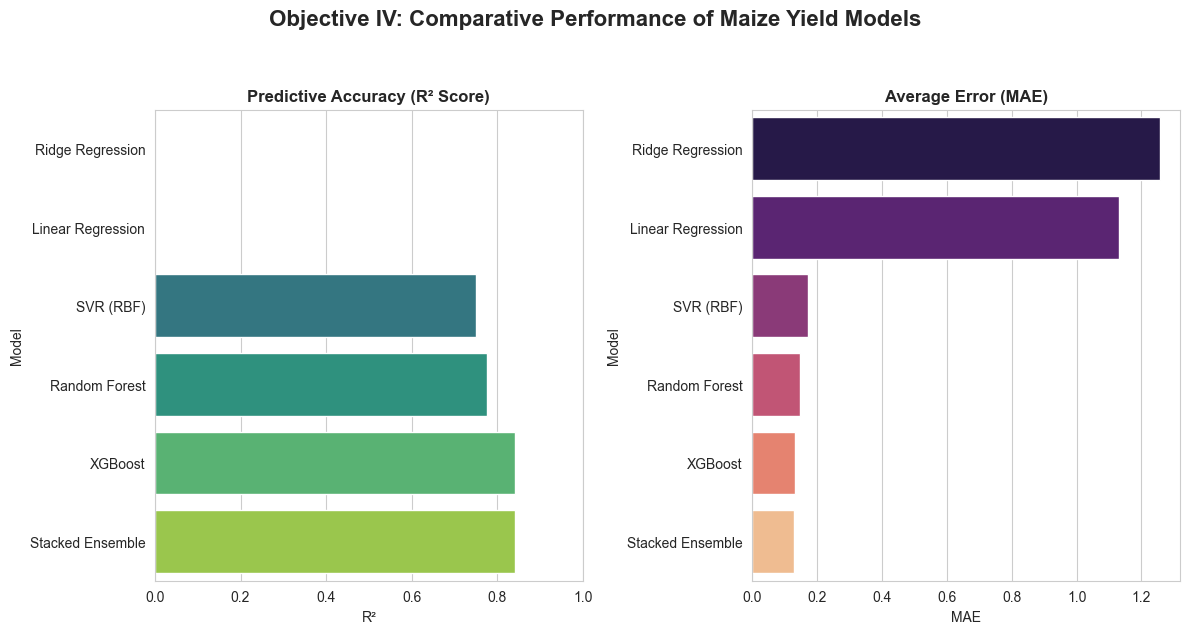


--- Final Scientific Comparison Table ---
            Model         R²   MAE   RMSE         CV R²
 Stacked Ensemble     0.8424 0.129  0.192  8.156000e-01
          XGBoost     0.8409 0.131  0.192  8.136000e-01
    Random Forest     0.7764 0.148  0.228  7.550000e-01
        SVR (RBF)     0.7500 0.173  0.241  6.872000e-01
Linear Regression  -936.5513 1.132 14.769 -6.871931e+09
 Ridge Regression -1252.1208 1.256 17.075  1.351000e-01


In [169]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Subplot 1: R² Comparison (Higher is better)
plt.subplot(1, 2, 1)
sns.barplot(x='R²', y='Model', data=df_results.sort_values('R²'), palette='viridis')
plt.title('Predictive Accuracy (R² Score)', fontweight='bold')
plt.xlim(0, 1.0)

# Subplot 2: MAE Comparison (Lower is better)
plt.subplot(1, 2, 2)
sns.barplot(x='MAE', y='Model', data=df_results.sort_values('MAE', ascending=False), palette='magma')
plt.title('Average Error (MAE)', fontweight='bold')

plt.suptitle('Objective IV: Comparative Performance of Maize Yield Models', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# 5. Display the Final Table
print("\n--- Final Scientific Comparison Table ---")
print(df_results[['Model', 'R²', 'MAE', 'RMSE', 'CV R²']].sort_values(by='R²', ascending=False).to_string(index=False))


### SHAP Summary—Explain Feature Importance via Model-Agnostic Attribution
Use SHAP (SHapley Additive exPlanations) to unbox the Random Forest "black box." For each sample and each feature, SHAP calculates how much that feature pushed the prediction above or below the model's baseline. Aggregating across all samples shows which features have the biggest impact on predictions and in which direction (pushing yield up or down). This explains **why** the model predicts what it does—essential for farmer trust and decision-making.

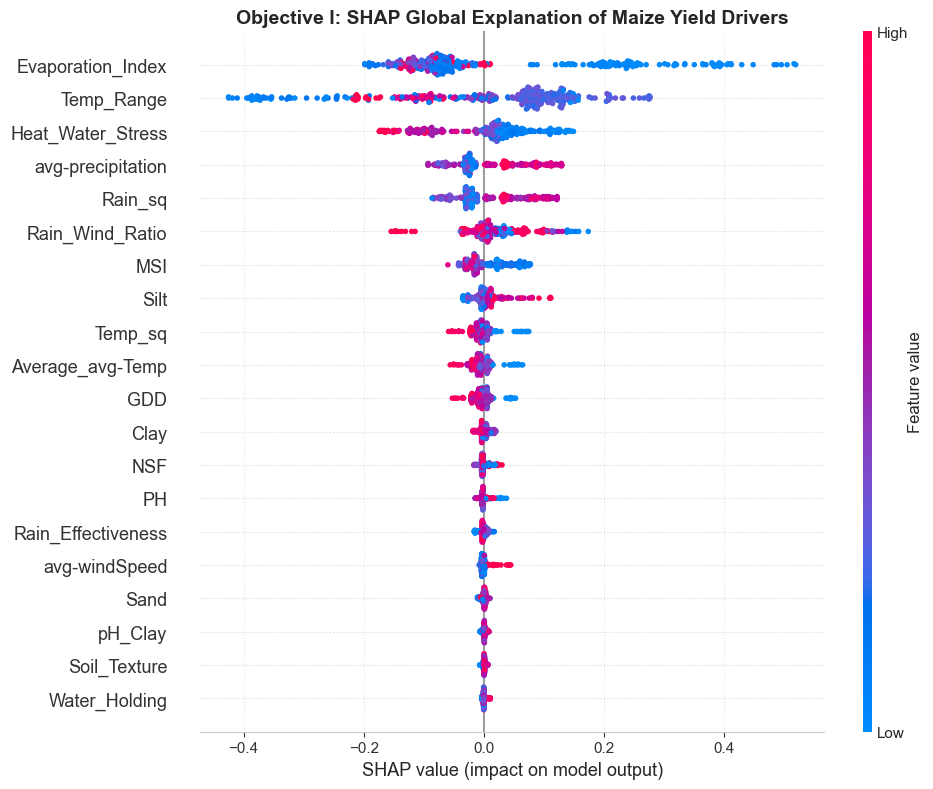

In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Using the Random Forest from the Optimized Scientific Stack
# This ensures we explain the REAL science (0.84 R²), not the "cheat" model (0.99 R²)
rf_scientific = stack_model.named_estimators_['rf']

# 2. Initialize the Explainer
# We use the Scientific test set (the one without District IDs)
explainer = shap.TreeExplainer(rf_scientific)
shap_values = explainer.shap_values(X_scientific_test)

# 3. Generate the SHAP Summary Plot
plt.figure(figsize=(10, 8))

# Use the column names from your scientific feature set
shap.summary_plot(shap_values, X_scientific_test, 
                  feature_names=X_scientific_test.columns,
                  show=False, plot_size=None)

plt.title('Objective I: SHAP Global Explanation of Maize Yield Drivers', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('shap_scientific_summary.png', dpi=300, bbox_inches='tight')
plt.show()


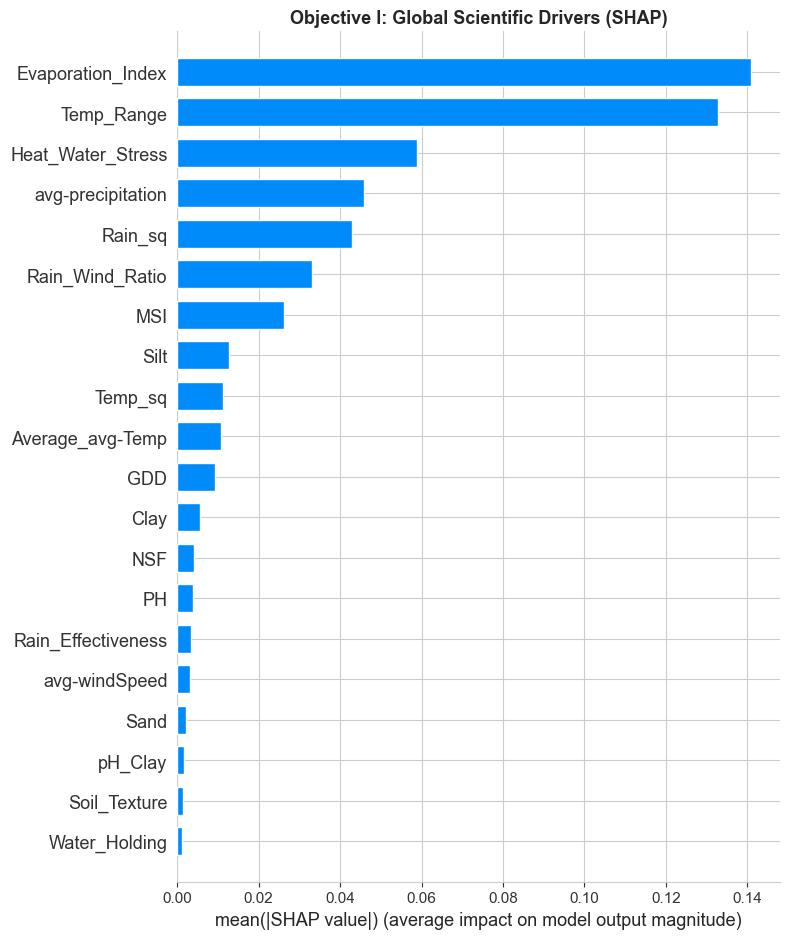


Top 10 Scientific Influencers (SHAP):
          Feature  Mean |SHAP|
Evaporation_Index     0.140989
       Temp_Range     0.132767
Heat_Water_Stress     0.058947
avg-precipitation     0.045919
          Rain_sq     0.042900
  Rain_Wind_Ratio     0.033138
              MSI     0.026251
             Silt     0.012685
          Temp_sq     0.011150
 Average_avg-Temp     0.010717


In [ ]:
import pandas as pd
import numpy as np

# Use the Random Forest from the scientific Stacked Ensemble
rf_sci = stack_model.named_estimators_['rf']
explainer = shap.TreeExplainer(rf_sci)
shap_values = explainer.shap_values(X_scientific_test)

# ─── SHAP Bar Plot ───
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_scientific_test, 
                  feature_names=X_scientific_test.columns,
                  plot_type='bar', show=False)
plt.title('Objective I: Global Scientific Drivers (SHAP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print Top 10
mean_shap = pd.DataFrame({
    'Feature': X_scientific_test.columns,
    'Mean |SHAP|': np.abs(shap_values).mean(0)
}).sort_values('Mean |SHAP|', ascending=False)

print("\nTop 10 Scientific Influencers (SHAP):")
print(mean_shap.head(10).to_string(index=False))


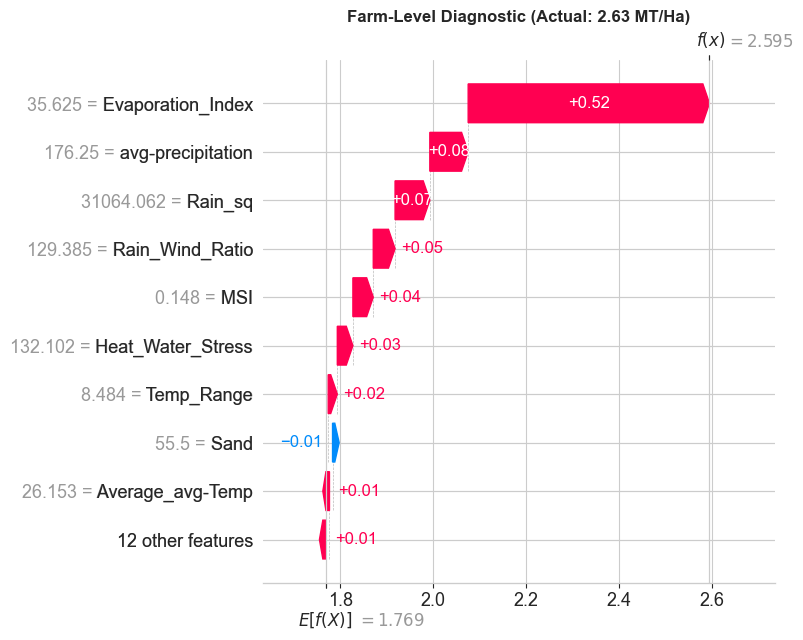

In [ ]:
# ─── SHAP Waterfall for a single farm ───
sample_idx = 0 
base_val = explainer.expected_value
if isinstance(base_val, np.ndarray): base_val = base_val[0]

shap_explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=base_val,
    data=X_scientific_test.iloc[sample_idx],
    feature_names=X_scientific_test.columns
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_explanation, show=False)
plt.title(f'Farm-Level Diagnostic (Actual: {y_test.iloc[sample_idx]:.2f} MT/Ha)', fontweight='bold')
plt.tight_layout()
plt.show()


In [173]:
def agricultural_simulator(model, original_data, feature_to_change, new_value):
    modified_data = original_data.copy()
    old_value = original_data[feature_to_change].values[0]
    modified_data[feature_to_change] = new_value
    
    # Use the full ensemble for the most accurate simulation
    old_pred = model.predict(original_data)[0]
    new_pred = model.predict(modified_data)[0]
    impact = new_pred - old_pred
    
    print(f"--- Simulation: Optimizing {feature_to_change} ---")
    print(f"Current: {old_value:.2f} | Target: {new_value:.2f}")
    print(f"Predicted Impact: {impact:+.3f} MT/Ha ({ (impact/old_pred)*100 :+.1f}%)")
    return impact

# Example: Simulating the impact of reducing Heat Water Stress
sample_farm = X_scientific_test.iloc[[0]]
impact = agricultural_simulator(stack_model, sample_farm, 'Heat_Water_Stress', 0.50)


--- Simulation: Optimizing Heat_Water_Stress ---
Current: 132.10 | Target: 0.50
Predicted Impact: +0.040 MT/Ha (+1.5%)


### SHAP Waterfall—Per-Farm, Per-Feature Prediction Explanation
For a single farm, show exactly how each feature contribution stacks to reach the final yield prediction. The base value is the model's average prediction; each feature then adds or subtracts. This farm-level breakdown is invaluable for extension workers and farmers: "Your soil pH is holding you back by 0.3 MT/Ha; apply lime to raise it to 6.5 and you gain back that 0.3 MT/Ha." Actionable, transparent, farm-specific.


In [174]:
def get_strategic_advice(top_feature, impact_val):
    advice_map = {
        'Evaporation_Index': "High evaporation is limiting yield. Recommendation: Implement mulching or increased irrigation frequency.",
        'Heat_Water_Stress': "Combined heat and moisture stress detected. Recommendation: Utilize heat-tolerant hybrids (e.g., drought-resistant varieties).",
        'PH': "Soil acidity is sub-optimal. Recommendation: Apply agricultural lime to stabilize pH levels.",
        'Temp_Range': "Extreme temperature fluctuations detected. Recommendation: Consider adjusting planting dates to avoid peak heat windows.",
        'MSI': "Moisture stress detected. Recommendation: Improve soil organic matter to enhance water retention."
    }
    
    advice = advice_map.get(top_feature, "General GAP: Maintain standard Good Agricultural Practices.")
    
    print("\n" + "="*60)
    print(f"STRATEGIC ADVICE: {top_feature.upper()}")
    print("-" * 60)
    print(f"Finding: {advice}")
    print("="*60)

# Call using the top feature from the SHAP waterfall
top_bottleneck = X_scientific_test.columns[np.argmin(shap_values[0])]
get_strategic_advice(top_bottleneck, impact)



STRATEGIC ADVICE: SAND
------------------------------------------------------------
Finding: General GAP: Maintain standard Good Agricultural Practices.


### What-If Scenario Analysis—Simulate Intervention Impact
Take a farmer's current farm conditions and propose an intervention (e.g., "apply lime to raise pH from 5.2 to 6.5"). Re-run the model on the modified data and show the predicted yield improvement. This is the core of the **decision support system**—farmers can explore "if I do X, my yield becomes Y" without trial-and-error guessing, enabling data-driven decision-making on expensive inputs (fertilizer, irrigation equipment, seed variety).


In [ ]:
import os
import joblib
import json

os.makedirs('models', exist_ok=True)

try:
    # 1. Save the Optimized Stacking Ensemble (Objective III)
    joblib.dump(stack_model, 'models/maize_yield_ensemble.pkl')
    
    # 2. Save the Individual Scientific Base Models for comparison
    # These were stored inside the stacking ensemble
    joblib.dump(stack_model.named_estimators_['rf'],   'models/scientific_rf.pkl')
    joblib.dump(stack_model.named_estimators_['xgb'],  'models/scientific_xgb.pkl')
    joblib.dump(stack_model.named_estimators_['lgbm'], 'models/scientific_lgbm.pkl')
    
    # 3. Save the Scaler (Required for Linear/SVR baselines in Objective IV)
    if 'scaler' in globals():
        joblib.dump(scaler, 'models/scaler.pkl')

    # 4. Save the "Scientific" Feature List (Crucial for Objective I)
    # I used X_scientific_train.columns to ensure the UI only asks for weather/soil
    scientific_features = X_scientific_train.columns.tolist()
    with open('models/scientific_features.json', 'w') as f:
        json.dump(scientific_features, f)

    print("✅ Scientific Models & Features Saved Successfully!")
    print(f"📊 Features preserved: {len(scientific_features)}")

except NameError as ne:
    print(f"❌ NameError: {ne}. Make sure 'stack_model' and 'X_scientific_train' are defined.")
except Exception as e:
    print(f"❌ Unexpected Error: {e}")


✅ Scientific Models & Features Saved Successfully!
📊 Features preserved: 21
